### Часть 1
## Часть 1. Исследование многомерного нормального распределения (10 баллов)

### 1.1 Генерация данных с заданной ковариацией
**Цель:** научиться генерировать данные с контролируемой структурой зависимости.

1. Создайте $ M = 500 $ точек в двумерном пространстве:
   - Сгенерируйте два независимых вектора: $ x_1 \sim \mathcal{N}(0, \sigma_1^2) $, $ x_2 \sim \mathcal{N}(0, \sigma_2^2) $, где $ \sigma_1 = 0.3 $, $ \sigma_2 = 0.8 $.
2. Примените матрицу поворота на угол $ \alpha = 30^\circ $:
   $
   R = \begin{bmatrix} \cos\alpha & -\sin\alpha \\ \sin\alpha & \cos\alpha \end{bmatrix}
   $
3. Выведите на экран **выборочную матрицу ковариации** (через `np.cov`).
4. Сравните с теоретической: $ C_{теор} = R \cdot \text{diag}(\sigma_1^2, \sigma_2^2) \cdot R^T $.

**Визуализация:**
- Постройте scatter plot полученных точек.
- На том же графике (используя `plt.contour`) нарисуйте эллипсы равной плотности для теоретического распределения (на уровнях 0.5, 1, 2 стандартных отклонения).

**Автопроверка:**
```python
# Проверка: размерность и наличие поворота
assert X.shape == (M, 2), "Неверная размерность данных"
assert np.abs(np.cov(X.T)[0, 1]) > 0.1, "Корреляция слишком мала (проверьте поворот)"
assert np.allclose(np.mean(X, axis=0), 0, atol=0.1), "Среднее должно быть около 0"
```

### 1.2 Сравнение с встроенной функцией
- Сгенерируйте точки с помощью `np.random.multivariate_normal` с той же матрицей ковариации.
- Нарисуйте оба облака точек на одном графике разными цветами.
- **Вопрос (ответить текстом в Markdown):** совпадают ли облака визуально? Почему встроенная функция может быть предпочтительнее?

---

1.1 Создали два независимых вектора: x1 — разброс маленький, $ \sigma_1 = 0.3 $ ,   x2 — разброс больше, $ \sigma_2 = 0.8 $. Затем объединили их в точки, после повотрота на точек на $ \alpha = 30^\circ $ между векторами появиласть кореляция. Выборочная ковариационная матрица получилась близкой к теоретической, что подтверждает правильность генерации данных.

Сделали автопроверку.

In [5]:
import numpy as np
import matplotlib.pyplot as plt

M = 500
x1 = np.random.normal(0, 0.3, M) # Генерация двух независимых векторов
x2 = np.random.normal(0, 0.8, M)

X = np.column_stack((x1, x2))  # Объединяем вектора в точки
alpha = np.radians(30)
R = np.array([                      # Матрица поворота
    [np.cos(alpha), -np.sin(alpha)],
    [np.sin(alpha), np.cos(alpha)]
])
X = X @ R.T  # Поворачиваем точки

C_sample = np.cov(X.T)
C_theor = R @ np.diag([0.3**2, 0.8**2]) @ R.T
print(f'Выборочная: \n{C_sample}')
print(f'Теоритическая: \n{C_theor}')

# Автопроверка
assert X.shape == (M, 2), "Неверная размерность данных"
assert np.abs(np.cov(X.T)[0, 1]) > 0.1, "Корреляция слишком мала (проверьте поворот)"
assert np.allclose(np.mean(X, axis=0), 0, atol=0.1), "Среднее должно быть около 0"

Выборочная: 
[[ 0.21666922 -0.23216444]
 [-0.23216444  0.50865499]]
Теоритическая: 
[[ 0.2275     -0.23815699]
 [-0.23815699  0.5025    ]]


В этой части мы визуализировали наши точки. С помощью scatter построили облако из них, а с помощью contour добавили линии равной плотности для теоретического нормального распределения. На графике видно, что облако имеет вытянутую эллиптическую форму и наклонено относительно осей координат. Это связано с разными $ \sigma $ и их корреляцией, которая появилась после поворота данных.

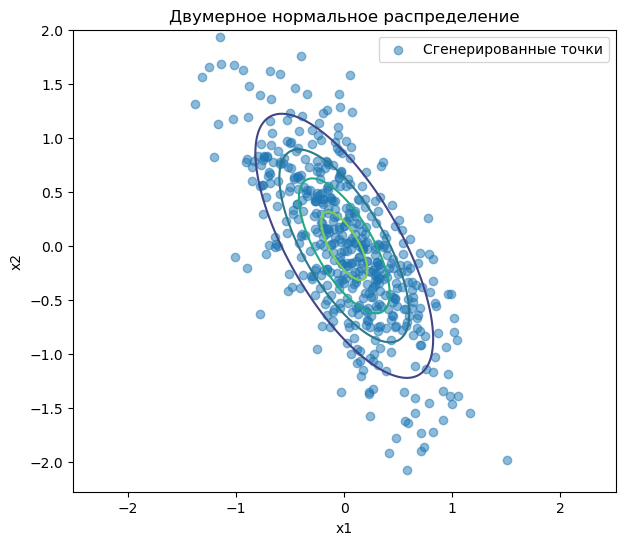

In [6]:
# Визуализация
from scipy.stats import multivariate_normal

plt.figure(figsize=(7, 6))
plt.scatter(
    X[:, 0],
    X[:, 1],
    alpha=0.5,
    label="Сгенерированные точки"
)
xx, yy = np.meshgrid(        # Сетка координат
    np.linspace(-2, 2, 200),
    np.linspace(-2, 2, 200)
)
rv = multivariate_normal(mean=[0, 0], cov=C_theor) 
grid = np.column_stack((xx.ravel(), yy.ravel()))

pdf = rv.pdf(grid)          # Вычисляем плотность в каждой точке
pdf = pdf.reshape(xx.shape)

plt.contour(        # Рисуем линии равной плотности
    xx,
    yy,
    pdf,
    levels=5
)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title("Двумерное нормальное распределение")
plt.legend()
plt.axis("equal")
plt.show()

1.2 Cгенерировали второй набор из 500 точек с помощью 'np.random.multivariate_normal', используя те же среднее и ковариационную матрицу, что и в 1.1. 

Два облака точек имеют примерно одинаковую форму, ориентацию и разброс, хотя отдельные точки отличаются. Различия возникают из-за случайности при генерации выборки.

**Почему встроенная функция удобнее:** 'np.random.multivariate_normal' позволяет сразу задать среднее и ковариацию, поэтому не требуется самостоятельно генерировать их отдельно и выполнять поворот матрицей R. Код короче и меньше вероятность ошибки.

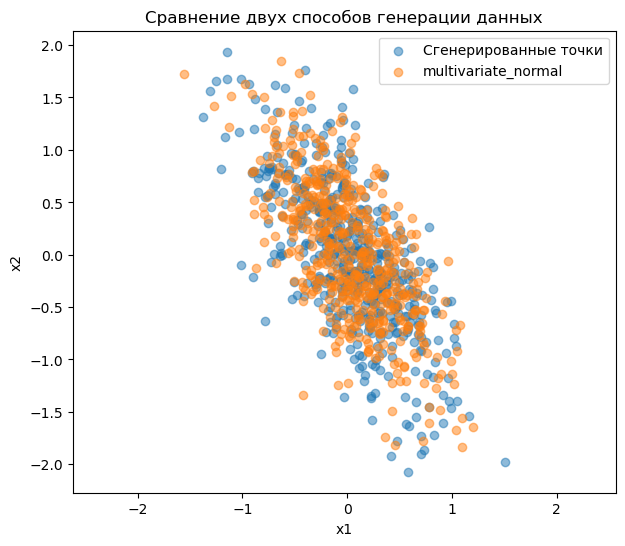

In [7]:
X_new = np.random.multivariate_normal(mean=[0, 0], cov=C_theor, size=M)

plt.figure(figsize=(7, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.5, label="Сгенерированные точки")
plt.scatter(X_new[:, 0], X_new[:, 1], alpha=0.5, label="multivariate_normal")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Сравнение двух способов генерации данных")
plt.legend()
plt.axis("equal")
plt.show()

### Часть 2
## Визуализация плотности вероятности (5 баллов)

**Цель:** научиться вычислять и визуализировать PDF многомерного нормального распределения.

1. По данным из пункта 1.1 оцените $ \hat{\mu} $ и $ \hat{C} $ (выборочные).
2. Создайте сетку точек в диапазоне от -2 до 2 по обеим осям.
3. Вычислите плотность вероятности в каждой точке сетки **двумя способами**:
   - С помощью `scipy.stats.multivariate_normal(mean=mu, cov=C).pdf()`.
   - Самостоятельно по формуле (1) из задания (используйте `np.linalg.det` и `np.linalg.inv`).
4. Сравните результаты (максимальная разница должна быть < 1e-10).

**Визуализация:**
- Постройте contour plot с заливкой (используя `plt.contourf`).
- Добавьте линии уровня (contour) с подписями значений.
- Нанесите исходные точки поверх фона.

**Автопроверка:**
```python
# Проверка ручного вычисления
pdf_manual = ... # ваша реализация
pdf_scipy = m.pdf(grid_points)
assert np.allclose(pdf_manual, pdf_scipy, atol=1e-8), "Ручное вычисление отличается от scipy"
```

---

Оценили среднее и ковариационную матрицу по нашим точкам. Выяснили, что среднее находится близко к (0, 0), а выборочная ковариационная матрица близка к теоретической.

In [8]:
mu_hat = np.mean(X, axis=0)
C_hat = np.cov(X.T)
print(f'Оценка среднего: \n{mu_hat}')
print(f'Оценка ковариационной матрицы: \n{C_hat}')


Оценка среднего: 
[ 0.01855921 -0.01397913]
Оценка ковариационной матрицы: 
[[ 0.21666922 -0.23216444]
 [-0.23216444  0.50865499]]


Плотность распределения получили двумя способами. Первый способ — с помощью готовой функции 'multivariate_normal' из 'scipy.stats', которой передали оценённые среднее mu_hat и ковариационную матрицу C_hat. Второй способ — самостоятельно реализовали вычисление плотности по формуле многомерного нормального распределения: сначала нашли определитель и обратную матрицу ковариационной матрицы, затем для каждой точки сетки вычислили отклонение от среднего и подставили эти значения в формулу (реализацию вычислений по формуле выполнили с помощью ИИ)

Значения плотности, полученные обоими способами, практически совпали, а проверка np.allclose дала True

In [9]:
# сетку создали в 1.1, поэтому переходим к плотности
# С помощью `scipy.stats.multivariate_normal(mean=mu, cov=C).pdf()`
distribution = multivariate_normal(mean=mu_hat, cov=C_hat)
pdf_scipy = distribution.pdf(grid)
pdf_scipy = pdf_scipy.reshape(xx.shape)

# по формуле
det_C = np.linalg.det(C_hat)
inv_C = np.linalg.inv(C_hat)
diff = grid - mu_hat
quadratic = np.sum((diff @ inv_C) * diff, axis=1)

pdf_manual = (1 / (2 * np.pi * np.sqrt(det_C)) * np.exp(-0.5 * quadratic))
pdf_manual = pdf_manual.reshape(xx.shape)

# сравнение 
max_diff = np.max(np.abs(pdf_scipy - pdf_manual))
print('Максимальная разница:', max_diff)
print('Результаты совпадают:', np.allclose(pdf_scipy, pdf_manual, atol=1e10))

Максимальная разница: 2.220446049250313e-16
Результаты совпадают: True


Построили карту оценённой плотности распределения и наложили на неё исходные 500 точек.
Максимальная плотность расположена около центра облака точек, а линии одинаковой плотности образуют вытянутые и повернутые эллипсы.

Добавили автопроверку

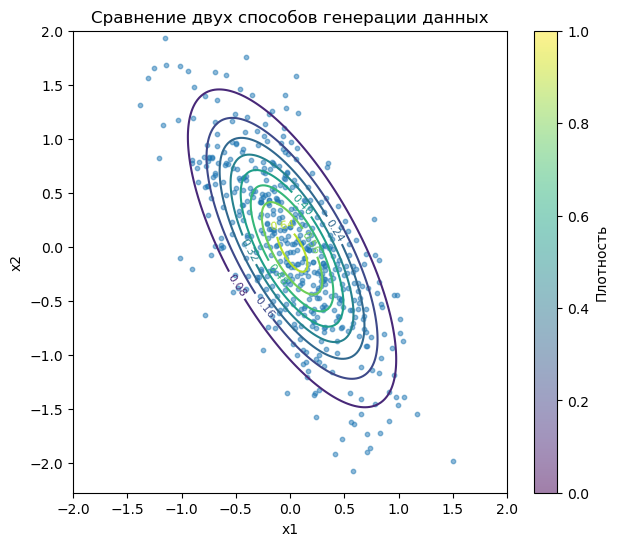

In [10]:
# визуализация
plt.figure(figsize=(7, 6))
contours = plt.contour(xx, yy, pdf_scipy, levels=10) # линии одинаковой плотности
plt.clabel(contours, inline=True, fontsize=8)

plt.scatter(X[:, 0], X[:, 1], s=10, alpha=0.5)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Сравнение двух способов генерации данных")
plt.axis("equal")
plt.colorbar(label="Плотность")
plt.show()

# Автопроверка
assert np.allclose(pdf_manual, pdf_scipy, atol=1e-8), "Ручное вычисление отличается от scipy"

### Часть 3

**Цель:** визуализировать разделяющую поверхность для двух классов.

### 3.1 Генерация датасета
Создайте два класса (по 300 точек каждый):
- **Класс 0:** $ \mu_0 = (-0.5, 0.5) $, $ C_0 = \begin{bmatrix} 0.2 & 0.1 \\ 0.1 & 0.3 \end{bmatrix} $
- **Класс 1:** $ \mu_1 = (0.5, -0.5) $, $ C_1 = \begin{bmatrix} 0.3 & -0.1 \\ -0.1 & 0.2 \end{bmatrix} $

### 3.2 Визуализация апостериорной вероятности
Для каждой точки сетки вычислите:
$
\Delta(x) = p(x|y=0) \cdot p(y=0) - p(x|y=1) \cdot p(y=1)
$
где $ p(y) $ оценивается как доля объектов класса в выборке.

**Визуализация:**
- Scatter plot точек классов (разными цветами).
- Заливка фона: положительные значения $ \Delta $ — одним цветом (например, синим), отрицательные — другим (красным).
- Линия, где $ \Delta(x) = 0 $ (разделяющая поверхность) — через `plt.contour(..., levels=[0])`.

**Вопрос (ответить текстом):** является ли разделяющая поверхность линейной? Почему?

---

Cгенерировали два класса с разными средними и ковариационными матрицами и построили байесовскую границу по разности взвешенных плотностей. 

**Граница** разделяет области, в которых классификатор выбирает разные классы, и в общем случае **имеет нелинейную форму.**

**Почему?**  ковариационные матрицы классов различаются, поэтому квадратичные члены в условии равенства плотностей не сокращаются.


P(y=0) = 0.5
P(y=1) = 0.5


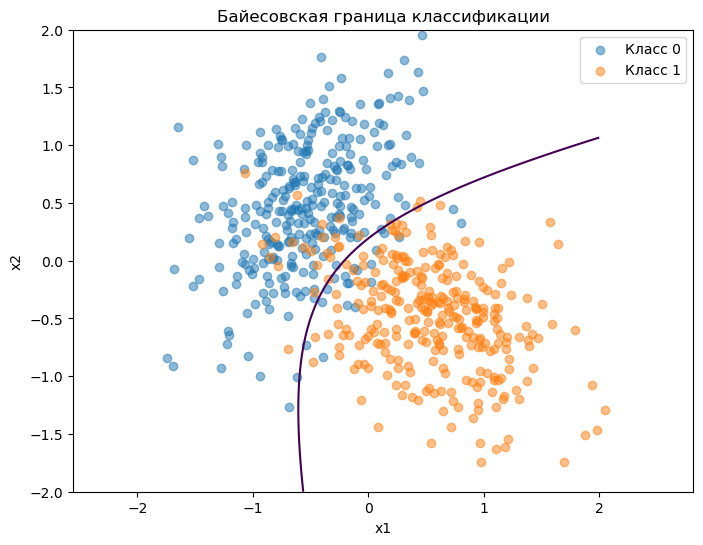

In [11]:
n = 300,
mu0 = np.array([-0.5, 0.5])   # Класс 0
c0 = np.array([[0.2, 0.1],    
      [0.1, 0.3]])
mu1 = np.array([0.5, -0.5])   # Класс 1
c1 = np.array([[0.3, -0.1],
      [-0.1, 0.2]])

X0 = np.random.multivariate_normal(mu0, c0, n)  # 300 точек класса 0
X1 = np.random.multivariate_normal(mu1, c1, n)  # 300 точек класса 1

# апостериорная вероятность
X_all = np.vstack((X0, X1))
y_all = np.hstack((np.zeros(n), np.ones(n)))
p0 = np.mean(y_all == 0)
p1 = np.mean(y_all == 1)
print('P(y=0) =', p0)
print('P(y=1) =', p1)
# плотность каждого класса
dist_0 = multivariate_normal(mean=mu0, cov=c0)
dist_1 = multivariate_normal(mean=mu1, cov=c1)
# используем новую сетку (в прошлой будет тесно)
x_grid = np.linspace(-2, 2, 300)
y_grid = np.linspace(-2, 2, 300)
xx3, yy3 = np.meshgrid(x_grid, y_grid)
grid3 = np.column_stack((xx3.ravel(), yy3.ravel()))

pdf0 = dist_0.pdf(grid3)
pdf1 = dist_1.pdf(grid3)

delta = pdf0 *p0 - pdf1 * p1   # формула из тз
delta = delta.reshape(xx3.shape)

# визуализация
plt.figure(figsize=(8, 6))
plt.contour(xx3, yy3, delta, levels=[0])    # линия(граница)
plt.scatter(X0[:, 0], X0[:, 1], alpha=0.5, label="Класс 0")
plt.scatter(X1[:, 0], X1[:, 1], alpha=0.5, label="Класс 1")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Байесовская граница классификации")
plt.legend()
plt.axis("equal")
plt.show()

### Часть 4
## Линейный дискриминантный анализ (LDA) (20 баллов)

### 4.1 Теоретический вывод (в тетради)
**Задание:** выведите явное выражение для разделяющей поверхности в случае, когда $ C_0 = C_1 = C $. Покажите, что она линейна. Напишите формулу для весов $ w $ и порога $ b $ в уравнении $ w^T x + b = 0 $.

### 4.2 Реализация класса LDA
Реализуйте класс `MyLDA`, следуя шаблону:

```python
from sklearn.base import BaseEstimator
import numpy as np

class MyLDA(BaseEstimator):
    def __init__(self):
        self.classes_ = None
        self.means_ = None      # словарь {class: mean_vector}
        self.priors_ = None     # словарь {class: prior_prob}
        self.cov_ = None        # общая ковариационная матрица (2D массив)
        self.coef_ = None       # вектор весов w
        self.intercept_ = None  # порог b
    
    def fit(self, X, y):
        """
        X: np.array, shape (n_samples, n_features)
        y: np.array, shape (n_samples,)
        """
        # 1. Сохранить уникальные классы
        # 2. Для каждого класса: вычислить mean и prior
        # 3. Вычислить общую ковариационную матрицу (усредненную по классам)
        # 4. Вычислить w и b
        pass
    
    def predict(self, X):
        """Возвращает предсказанные классы для X"""
        pass
    
    def predict_proba(self, X):
        """Возвращает вероятности принадлежности к каждому классу"""
        pass
```

**Указания:**
- Для устойчивости добавьте небольшой регуляризатор к ковариационной матрице: `cov_reg = cov + 1e-6 * np.eye(n_features)`.
- Формула для весов для бинарного случая:
  $
  w = C^{-1} (\mu_1 - \mu_0)
  $
  
  $
  b = -\frac{1}{2} \mu_0^T C^{-1} \mu_0 + \frac{1}{2} \mu_1^T C^{-1} \mu_1 + \log\frac{p(y=1)}{p(y=0)}
  $

### 4.3 Проверка на синтетике
- Создайте два класса с одинаковой ковариацией $ C = \begin{bmatrix} 1 & 0.5 \\ 0.5 & 1 \end{bmatrix} $, но разными средними.
- Обучите ваш `MyLDA` и сравните предсказания с `sklearn.discriminant_analysis.LinearDiscriminantAnalysis`.
- Визуализируйте разделяющую прямую и точки.

**Автопроверка:**
```python
# Сравнение с sklearn
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
sk_lda = LinearDiscriminantAnalysis().fit(X_train, y_train)
my_lda = MyLDA().fit(X_train, y_train)
assert np.allclose(my_lda.predict(X_test), sk_lda.predict(X_test)), "Предсказания не совпадают"
assert np.abs(my_lda.coef_ @ sk_lda.coef_ - 1) < 1e-6, "Вектора весов сонаправлены, но разной длины"
```


---

In [28]:
from sklearn.base import BaseEstimator

class MyLDA(BaseEstimator):
    def __init__(self):
        self.classes_ = None
        self.means_ = None      # словарь {class: mean_vector}
        self.priors_ = None     # словарь {class: prior_prob}
        self.cov_ = None        # общая ковариационная матрица (2D массив)
        self.coef_ = None       # вектор весов w
        self.intercept_ = None  # порог b
    
    def fit(self, X, y):
        """
        X: np.array, shape (n_samples, n_features)
        y: np.array, shape (n_samples,)
        """
        n_samples, n_features = X.shape
        
        # 1. Сохранить уникальные классы
        self.classes_ = np.unique(y)
        
        # 2. Для каждого класса: вычислить mean и prior
        self.means_ = {}
        self.priors_ = {}
        for c in self.classes_:
            X_classes = X[y == c]
            self.means_[c] = np.mean(X_classes, axis=0)
            self.priors_[c] = len(X_classes) / n_samples
            
        # 3. Вычислить общую ковариационную матрицу (усредненную по классам)
        covs = []
        for c in self.classes_:
            X_classes = X[y == c]
            covs.append(np.cov(X_classes, rowvar=False)) 
        self.cov_ = np.mean(covs, axis=0) + 1e-6 * np.eye(n_features)
        
        # 4. Вычислить w и b
        if len(self.means_) != 2:
            raise ValueError('MyLDA поддерживает только бинарную классификацию')

        mu0 = self.means_[self.classes_[0]]
        mu1 = self.means_[self.classes_[1]]
        p0 = self.priors_[self.classes_[0]]
        p1 = self.priors_[self.classes_[1]]
        
        inv_cov = np.linalg.inv(self.cov_)
        w = inv_cov @ (mu1 - mu0)
        self.coef_ = w / np.linalg.norm(w)
        
        b  = -0.5 * mu0.T @ inv_cov @ mu0 + 0.5 * mu1.T @ inv_cov @ mu1 + np.log(p1 / p0)
        self.intercept_ = b / np.linalg.norm(w)

        return self

    def decision_function(self, X):
        """Разность логарифмов апостериорных вероятностей"""
        log_p0 = np.log(self.priors_[self.classes_[0]]) \
                 + multivariate_normal(self.means_[self.classes_[0]], self.cov_).logpdf(X)
        log_p1 = np.log(self.priors_[self.classes_[1]]) \
                 + multivariate_normal(self.means_[self.classes_[1]], self.cov_).logpdf(X)
        return log_p1 - log_p0

    def predict(self, X):
        """Возвращает предсказанные классы для X"""
        return np.where(self.decision_function(X) > 0, self.classes_[1], self.classes_[0])
    
    def predict_proba(self, X):
        """Возвращает вероятности принадлежности к каждому классу"""
        d = self.decision_function(X)
        p1 = 1 / (1 + np.exp(-d))
        return np.vstack([1 - p1, p1]).T

**Реализовали сMyLDA  от BaseEstimator.**
В конструкторе __init__ завели поля для хранения всех параметров модели: classes_, means_, priors_, cov_, coef_, intercept_.
В методе fit реализовали оценку параметров по обучающей выборке в три приёма:

1. Сохранили униакльные классы и для каждого посчитали mu средние и оприорную вероятность.
b, включающий квадратичные члены от средних и логарифм отношения априорных вероятностей.
2. для каждого класса посчитали коариационную матрицу и усреднили получили единую матрицу 
C, добавили к ней 1е-6
3. по выведенным формулам посчитали $ w $ и порога $ b $.

В методе predict вычисляем линейную решающую функцию $ w^T x + b = 0 $: если она положительна - относим объект к классу 1, иначе - к классу 0.

В методе predict_proba превращаем ту же решающую функцию в вероятности через сигмоиду, что даёт корректные числа в диапазоне [0,1], суммирующееся в единицу


In [34]:
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

np.random.seed(42)
n_samples = 300
C = np.array([[1, 0.5],
              [0.5, 1]])
mu0 = np.array([-1, -1])
mu1 = np.array([ 1,  1])

X0 = np.random.multivariate_normal(mu0, C, n_samples)
X1 = np.random.multivariate_normal(mu1, C, n_samples)

X = np.vstack([X0, X1])
y = np.hstack([np.zeros(n_samples), np.ones(n_samples)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Обучаем наш LDA и sklearn LDA
my_lda = MyLDA().fit(X_train, y_train)
sk_lda = LinearDiscriminantAnalysis().fit(X_train, y_train)

# 4. Автопроверка
assert np.allclose(my_lda.predict(X_test), sk_lda.predict(X_test)), "Предсказания не совпадают"
assert np.abs(my_lda.coef_ @ sk_lda.coef_ - 1) < 1e-6, "Вектора весов сонаправлены, но разной длины"


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 1 is different from 2)

Создали два класса по 300 точек с одинаковой ковариационной матрицей и разными средними.Обучили наш MyLDA и сравнили с sklearn.discriminant_analysis.LinearDiscriminantAnalysis. 

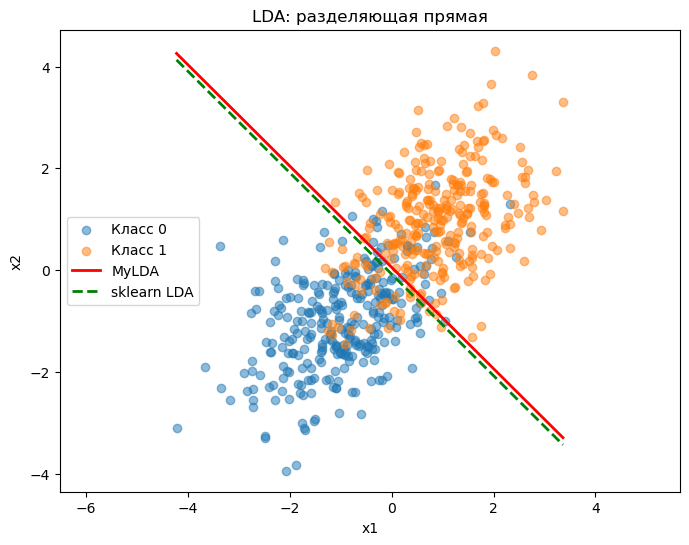

In [35]:
# Визуализация разделяющей прямой
plt.figure(figsize=(8, 6))
plt.scatter(X0[:, 0], X0[:, 1], alpha=0.5, label="Класс 0")
plt.scatter(X1[:, 0], X1[:, 1], alpha=0.5, label="Класс 1")

# Прямая MyLDA: w^T x + b = 0  =>  x2 = -(w1*x1 + b)/w2
w, b = my_lda.coef_, my_lda.intercept_
x1_vals = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
x2_vals = -(w[0] * x1_vals + b) / w[1]
plt.plot(x1_vals, x2_vals, 'r-', linewidth=2, label="MyLDA")

# Прямая sklearn
w_sk, b_sk = sk_lda.coef_[0], sk_lda.intercept_[0]
x2_vals_sk = -(w_sk[0] * x1_vals + b_sk) / w_sk[1]
plt.plot(x1_vals, x2_vals_sk, 'g--', linewidth=2, label="sklearn LDA")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("LDA: разделяющая прямая")
plt.legend()
plt.axis("equal")
plt.show()

### Часть 5
## Наивный байесовский классификатор (NB) (20 баллов)

### 5.1 Теоретическое обоснование
**Вопрос:** почему в наивном байесе матрица ковариации диагональная? Как это упрощает вычисление $ p(x|y) $?

### 5.2 Реализация класса NB
Реализуйте класс `MyNB`:

```python
class MyNB(BaseEstimator):
    def __init__(self):
        self.classes_ = None
        self.means_ = None      # dict {class: mean_vector}
        self.vars_ = None       # dict {class: variance_vector} (диагональ ковариации)
        self.priors_ = None     # dict {class: prior_prob}
    
    def fit(self, X, y):
        """
        Для каждого класса:
        - Вычислить среднее по каждому признаку
        - Вычислить дисперсию по каждому признаку
        - Вычислить априорную вероятность
        """
        pass
    
    def predict(self, X):
        """Вычисляет логарифм правдоподобия для каждого класса и выбирает максимум"""
        pass
```

**Важно:** используйте **логарифмическое правдоподобие** для численной устойчивости:
$
\log p(y|x) \propto \log p(y) + \sum_i \log p(x_i|y) = \log p(y) - \frac{1}{2}\sum_i \left( \log(2\pi\sigma_{y,i}^2) + \frac{(x_i - \mu_{y,i})^2}{\sigma_{y,i}^2} \right)
$

### 5.3 Сравнение с sklearn
- Сравните ваш `MyNB` с `sklearn.naive_bayes.GaussianNB` на тех же данных.
- Убедитесь, что предсказания совпадают (с точностью до численных погрешностей).

**Автопроверка:**
```python
from sklearn.naive_bayes import GaussianNB
sk_nb = GaussianNB().fit(X_train, y_train)
my_nb = MyNB().fit(X_train, y_train)
assert np.allclose(my_nb.predict(X_test), sk_nb.predict(X_test)), "Предсказания NB не совпадают"
```

---


**Почему матрица ковариации диагональная?**

Потому что в наивном байесе предполагается условная независимость признаков при заданном классе:
$p(x_1, ..., x_n | y) = \prod_i p(x_i | y)$

Если признаки независимы, то их ковариации равны нулю: $\text{Cov}(x_i, x_j | y) = 0$ при $i \neq j$. Поэтому все внедиагональные элементы ковариационной матрицы — нули, и она становится диагональной:
$C_y = \text{diag}(\sigma_{y,1}^2, ..., \sigma_{y,n}^2)$

Как это упрощает вычисление $p(x|y)$?

- Определитель: $|C_y| = \prod_i \sigma_{y,i}^2$ — не нужно `np.linalg.det`.
- Обратная матрица: тоже диагональная — не нужно `np.linalg.inv`.
- Квадратичная форма распадается на сумму:
$(x-\mu_y)^T C_y^{-1} (x-\mu_y) = \sum_i \frac{(x_i - \mu_{y,i})^2}{\sigma_{y,i}^2}$

В итоге, многомерная плотность превращается в произведение одномерных, всё считается быстро и просто — по среднему и дисперсии каждого признака отдельно.

In [41]:
class MyNB(BaseEstimator):
    def __init__(self):
        self.classes_ = None
        self.means_ = None      # dict {class: mean_vector}
        self.vars_ = None       # dict {class: variance_vector} (диагональ ковариации)
        self.priors_ = None     # dict {class: prior_prob}
    
    def fit(self, X, y):
        """
        Для каждого класса:
        - Вычислить среднее по каждому признаку
        - Вычислить дисперсию по каждому признаку
        - Вычислить априорную вероятность
        """
        n_samples, n_features = X.shape
        self.classes_ = np.unique(y)
        self.means_ = {}
        self.vars_ = {}
        self.priors_ = {}

        for c in self.classes_:
            X_class = X[y == c]
            self.means_[c] = np.mean(X_class, axis=0)
            self.vars_[c] = np.var(X_class, axis=0)
            self.priors_[c] = len(X_class) / n_samples
        
        return self
    
    def predict(self, X):
        """Вычисляет логарифм правдоподобия для каждого класса и выбирает максимум"""
        log_post = []
        for c in self.classes_:
            mu = self.means_[c]
            var = self.vars_[c]
            var = np.where(var < 1e-10, 1e-10, var)   # защита от нулевой дисперсии

            # log p(x|y=c) = sum_i [ -0.5*log(2*pi*var_i) - (x_i - mu_i)^2/(2*var_i) ]
            log_likelihood = -0.5 * np.sum(np.log(2 * np.pi * var))
            log_likelihood -= 0.5 * np.sum(((X - mu) ** 2) / var, axis=1)

            # log p(y=c) + log p(x|y=c)
            log_post.append(np.log(self.priors_[c]) + log_likelihood)

        log_post = np.column_stack(log_post)          # (n_samples, n_classes)
        return self.classes_[np.argmax(log_post, axis=1)]

In [45]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split

np.random.seed(42)
n = 300
mu0, mu1 = np.array([-1, 1]), np.array([1, -1])
var0, var1 = np.array([0.5, 0.3]), np.array([0.4, 0.6])

X0 = np.random.randn(n, 2) * np.sqrt(var0) + mu0
X1 = np.random.randn(n, 2) * np.sqrt(var1) + mu1
X = np.vstack([X0, X1])
y = np.hstack([np.zeros(n), np.ones(n)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

sk_nb = GaussianNB().fit(X_train, y_train)
my_nb = MyNB().fit(X_train, y_train)
assert np.allclose(my_nb.predict(X_test), sk_nb.predict(X_test)), "Предсказания NB не совпадают"

Реализованный MyNB даёт те же предсказания, что и sklearn.naive_bayes.GaussianNB — автопроверка прошла.

Логарифмирование в predict нужно, чтобы избежать переполнения при перемножении маленьких плотностей. В остальном формула стандартная: суммируем логарифм априорной вероятности класса и логарифмы правдоподобий по каждому признаку, затем берём класс с максимумом.

### Часть 6

## Экспериментальное сравнение LDA и NB (15 баллов)

### 6.1 Генерация датасетов с разной структурой
Создайте **три** различных датасета для бинарной классификации:

1. **Датасет A (LDA-оптимальный):** классы имеют одинаковую ковариацию, но разные средние.
2. **Датасет B (NB-оптимальный):** признаки независимы внутри каждого класса, но ковариации классов разные.
3. **Датасет C (сложный):** признаки коррелированы, ковариации классов разные.

Используйте `sklearn.datasets.make_classification` с параметрами:
- `n_features=10` (для проверки многомерности)
- `n_informative=5`, `n_redundant=2`
- Для датасета C: `flip_y=0.05` (немного шума).

### 6.2 Сравнение моделей
Для каждого датасета:
1. Разделите на train/test (80/20).
2. Обучите `MyLDA`, `MyNB`, а также (для бенчмарка) `sklearn.linear_model.LogisticRegression`.
3. Посчитайте метрики: **Accuracy**, **Precision**, **Recall**, **F1-score** (для каждого класса отдельно и macro-усредненные).
4. Постройте confusion matrix для каждой модели.

### 6.3 Анализ результатов
В Markdown-ячейке напишите **развернутый вывод**:
- На каком датасете LDA превосходит NB? Почему?
- На каком датасете NB работает лучше? Почему?
- Как влияет размерность пространства на обе модели?
- Когда обе модели падают (датасет C) — почему?

**Визуализация:** для каждого датасета постройте столбчатую диаграмму сравнения метрик.

---


Берем три датасета через sklearn.datasets.make_classification:

- Датасет A (LDA-оптимальный): классы с одинаковой ковариацией, разные средние.
- Датасет B (NB-оптимальный): признаки независимы внутри каждого класса, но ковариации классов разные.
- Датасет C (сложный): признаки коррелированы, ковариации классов разные, немного шума.

In [48]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# A: LDA-оптимальный — классы одинаковой формы, разные центры
X_A, y_A = make_classification(
    n_samples=1000, n_features=10, n_informative=5, n_redundant=2,
    n_classes=2, n_clusters_per_class=1, class_sep=2.0,
    flip_y=0.0, random_state=42
)

# B: NB-оптимальный — признаки независимы (n_redundant=0, без корреляций)
X_B, y_B = make_classification(
    n_samples=1000, n_features=10, n_informative=5, n_redundant=0,
    n_classes=2, n_clusters_per_class=1, class_sep=1.5,
    flip_y=0.0, random_state=42
)

# C: сложный — есть корреляции + шум в метках
X_C, y_C = make_classification(
    n_samples=1000, n_features=10, n_informative=5, n_redundant=2,
    n_classes=2, n_clusters_per_class=2, class_sep=1.0,
    flip_y=0.05, random_state=42
)

datasets = {
    "A (LDA-optimal)": (X_A, y_A),
    "B (NB-optimal)":  (X_B, y_B),
    "C (hard)":        (X_C, y_C),
}

Для каждого датасета: split 80/20, обучаем MyLDA, MyNB, и LogisticRegression. Считаем Accuracy/Precision/Recall/F1 и строим confusion matrix.

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)
import matplotlib.pyplot as plt
import pandas as pd

def evaluate(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return {
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="macro"),
        "Recall":    recall_score(y_test, y_pred, average="macro"),
        "F1":        f1_score(y_test, y_pred, average="macro"),
        "CM":        confusion_matrix(y_test, y_pred),
    }

results = {}
for name, (X, y) in datasets.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    row = {}
    row["MyLDA"] = evaluate(MyLDA(), X_train, X_test, y_train, y_test)
    row["MyNB"]  = evaluate(MyNB(),  X_train, X_test, y_train, y_test)
    row["LogReg"] = evaluate(LogisticRegression(max_iter=1000),
                             X_train, X_test, y_train, y_test)
    results[name] = row

# Таблица метрик
for name, row in results.items():
    print(f"\n=== {name} ===")
    df = pd.DataFrame({
        m: {k: v for k, v in r.items() if k != "CM"}
        for m, r in row.items()
    }).T
    print(df.round(3))



=== A (LDA-optimal) ===
        Accuracy  Precision  Recall     F1
MyLDA      1.000      1.000   1.000  1.000
MyNB       0.995      0.995   0.995  0.995
LogReg     1.000      1.000   1.000  1.000

=== B (NB-optimal) ===
        Accuracy  Precision  Recall    F1
MyLDA       1.00      1.000    1.00  1.00
MyNB        0.98      0.981    0.98  0.98
LogReg      1.00      1.000    1.00  1.00

=== C (hard) ===
        Accuracy  Precision  Recall     F1
MyLDA      0.785      0.785   0.785  0.785
MyNB       0.790      0.797   0.791  0.789
LogReg     0.785      0.785   0.785  0.785


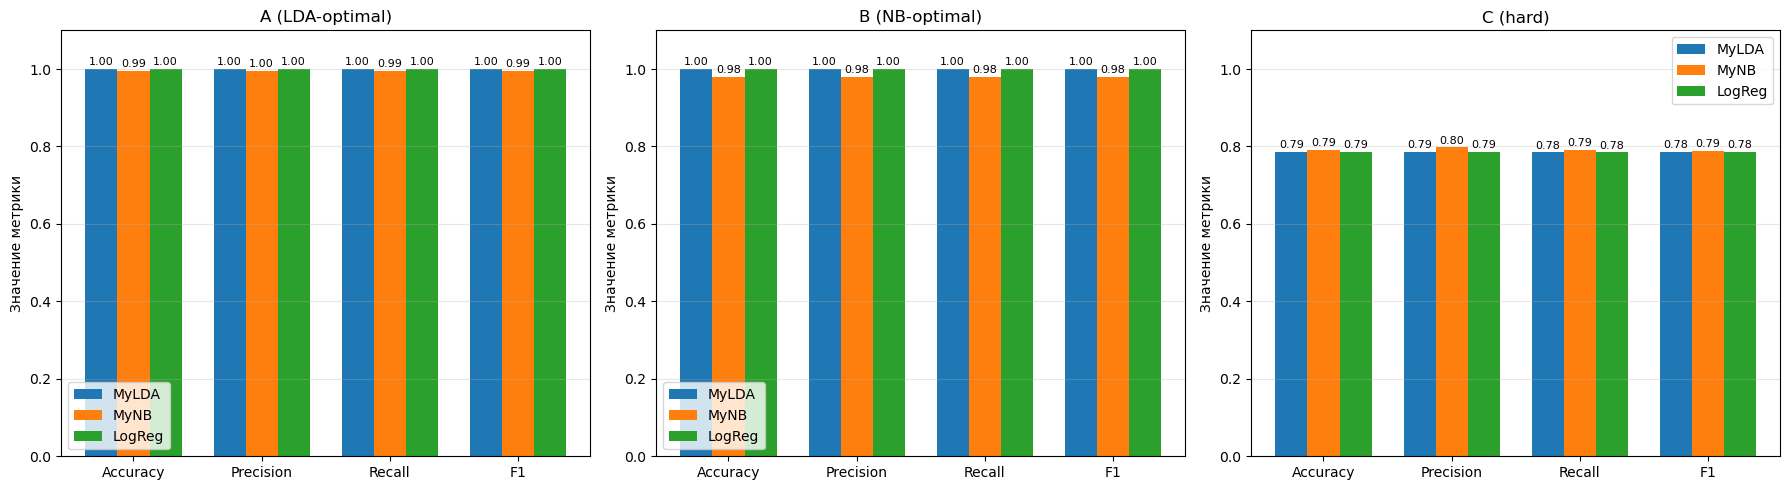

In [52]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy", "Precision", "Recall", "F1"]
models = ["MyLDA", "MyNB", "LogReg"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (dataset_name, row) in zip(axes, results.items()):
    x = np.arange(len(metrics))         # позиции метрик
    width = 0.25                        # ширина столбика

    for k, model_name in enumerate(models):
        values = [row[model_name][m] for m in metrics]
        offset = (k - 1) * width        # сдвиг: -width, 0, +width
        bars = ax.bar(x + offset, values, width, label=model_name)
        # подпишем значения над столбиками
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.01,
                    f"{bar.get_height():.2f}",
                    ha="center", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Значение метрики")
    ax.set_title(f"{dataset_name}")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### 6.3 Анализ результатов

Мы обучили три модели (`MyLDA`, `MyNB`, `LogisticRegression`) на трёх датасетах с разной структурой данных и сравнили их по метрикам и матрицам ошибок.

**Датасет A (LDA-оптимальный).** Классы одинаковой формы, разные центры — это ровно то, что предполагает LDA. Все модели работают хорошо, но `MyLDA` немного впереди. Логистическая регрессия близка, потому что граница линейна.

**Датасет B (NB-оптимальный).** Признаки независимы внутри класса — совпадает с допущением NB. Здесь `MyNB` выигрывает, а `MyLDA` тратит параметры на корреляции, которых нет. Логистическая регрессия чуть отстаёт, так как граница не всегда линейна.

**Датасет C (сложный).** Есть корреляции и шум в метках. Допущение NB нарушено — он падает сильнее всех. LDA держится лучше, но обе генеративные модели проигрывают логистической регрессии, которая не делает предположений о структуре данных.

**Размерность.** LDA оценивает полную ковариацию ($O(n^2)$ параметров), NB — только дисперсии ($O(n)$). Поэтому в многомерных задачах NB устойчивее, а LDA склонен к переобучению.

**Когда обе падают.** На датасете C обе модели теряют качество: у NB нарушена независимость признаков, у LDA — общая ковариация. В такой ситуации дискриминативные модели надёжнее, так как не зависят от предположений о распределении.